In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import filtfilt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载分组结果和滤波器参数
groups_df = pd.read_csv(r'../数据/噪声分组.csv')
filter_params_df = pd.read_csv(r'../数据/滤波器参数设置.csv')

print("\n[1] 加载分组结果:")
print(groups_df[['code', 'group', 'noise_score']].head())

print("\n[2] 加载滤波器参数:")
print(filter_params_df[['code', 'group', 'cutoff_period', 'filter_order', 'filter_type']].head())#打印前5跳数据

# 加载股票价格数据
data_dir = Path(r"../数据/沪深300权重前20位股票3年基本数据") 
stock_data = {}

for code in groups_df['code'].tolist():
    csv_path = data_dir / f"{code}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)#读取数据
        df['trade_date'] = pd.to_datetime(df['trade_date'])#将交易日期字符串转换成 Pandas 能识别的日期格式
        df = df.sort_values('trade_date').reset_index(drop=True)#按交易日期从小到大排序，并重置索引（避免乱序）
        df['close'] = pd.to_numeric(df['close'], errors='coerce')#把收盘价转成数字类型，遇到错误自动设为 NaN（空值）
        df = df.dropna(subset=['close'])# 删除收盘价为空的行，保证数据干净
        stock_data[code] = df# 把处理好的干净数据存入字典，方便后续批量处理
        print(f"加载 {code}: {len(df)} 条记录")
    else:
        print(f"未找到 {code}.csv")

print(f"\n成功加载 {len(stock_data)} 只股票数据")


[1] 加载分组结果:
        code group  noise_score
0  002594.SZ  高噪声组     0.744727
1  688256.SH  高噪声组     0.600136
2  300502.SZ  高噪声组     0.587884
3  300750.SZ  高噪声组     0.554915
4  300308.SZ  高噪声组     0.514656

[2] 加载滤波器参数:
        code group  cutoff_period  filter_order  filter_type
0  002594.SZ  高噪声组      44.182353             6    chebyshev
1  688256.SH  高噪声组      46.733225             4  butterworth
2  300502.SZ  高噪声组      49.789934             5    chebyshev
3  300750.SZ  高噪声组      30.265735             6    chebyshev
4  300308.SZ  高噪声组      45.208961             4    chebyshev
加载 002594.SZ: 725 条记录
加载 688256.SH: 725 条记录
加载 300502.SZ: 725 条记录
加载 300750.SZ: 725 条记录
加载 300308.SZ: 725 条记录
加载 300059.SZ: 725 条记录
加载 688041.SH: 715 条记录
加载 688981.SH: 719 条记录
加载 603259.SH: 725 条记录
加载 600030.SH: 725 条记录
加载 601318.SH: 725 条记录
加载 600519.SH: 725 条记录
加载 601166.SH: 725 条记录
加载 002475.SZ: 725 条记录
加载 600276.SH: 725 条记录
加载 600036.SH: 725 条记录
加载 601899.SH: 725 条记录
加载 000333.SZ: 725 条记录
加载 601398.SH: 725 条

In [3]:
#设计低通滤波器
import scipy.signal as signal#滤波器算法的导入
def design_lowpass_filter(cutoff_freq, fs=1.0, order=4, filter_type='butterworth'):
    """
    参数:
    - cutoff_freq: 截止频率 (Hz)，高于这个频率将被删除
    - fs: 采样频率 (默认1，表示1天1个样本)
    - order: 滤波器阶数，阶数越高，滤波效果越陡
    - filter_type: 'butterworth' 或 'chebyshev'滤波器类型
    
    返回:
    - b, a: 滤波器系数
    """
    nyquist = fs / 2#能处理的最高有效频率 = 采样频率的一半
    normalized_cutoff = cutoff_freq / nyquist
     # 安全限制：归一化频率不能 ≥1
    if normalized_cutoff >= 1.0:
        normalized_cutoff = 0.99
    
    if filter_type == 'butterworth':
        b, a = signal.butter(order, normalized_cutoff, btype='low')
    elif filter_type == 'chebyshev':
        b, a = signal.cheby1(order, 0.5, normalized_cutoff, btype='low')
    else:
        b, a = signal.butter(order, normalized_cutoff, btype='low')
    
    return b, a

In [4]:
#应用零相位滤波器（避免相位延迟），在通过低通滤波器筛去高频的噪声信号后消去相位延迟，与原始数据对齐
def apply_filter(price_series, b, a):
    # 保留索引，避免错位
    valid_idx = price_series.dropna().index
    price_clean = price_series.loc[valid_idx].values#提取有效数据，纯数字的数组
    filtered = filtfilt(b, a, price_clean)
    
    # 返回带索引的序列
    filtered_series = price_series.copy()#保留日期和结构
    filtered_series.loc[valid_idx] = filtered#填回数据，保证对齐
    return filtered_series

In [5]:
def apply_filter_to_stock(price_series, cutoff_period, order=4, filter_type='butterworth'):
    """
    股票专用：直接传入 周期参数，自动转频率 + 滤波
    """
    # 复制一份，避免修改原数据
    price = price_series.copy()
    # 股票核心：周期 → 频率 转换
    if cutoff_period <= 1:
        cutoff_period = 2  # 防止除0
    
    cutoff_freq = 1.0 / cutoff_period  # 周期转频率
    fs = 1.0  # 日线：1天1个点

     # 记录有效索引（非 NaN 位置）
    valid_mask = price.notna()
    price_valid = price[valid_mask]  # 只拿干净数据滤波
    
    if len(price_valid) == 0:
        # 全是空值，返回全空序列
        return pd.Series(index=price.index, dtype=price.dtype), None, None

    # 设计滤波器
    b, a = design_lowpass_filter(
        cutoff_freq=cutoff_freq,
        fs=fs,
        order=order,
        filter_type=filter_type
    )
    
    # 零相位滤波
    filtered_clean = apply_filter(price_valid, b, a)
    
    # 把滤波结果还原成带日期索引的Series（保持对齐）
    filtered_series = pd.Series(index=price.index, dtype=price.dtype)
    filtered_series.loc[valid_mask[valid_mask].index] = filtered_clean#填上滤波后的数据
    
    return filtered_series, b, a

In [6]:
def evaluate_filter_performance(original, filtered, residual):#三个输入，原始股价，过滤后的股价和残差（过滤后的噪声）
    # 去无效值
    mask = original.notna() & filtered.notna()#找到原始数据不为空且滤波数据也不为空的位置
    orig = original[mask]
    filt = filtered[mask]
    res = residual[mask]
    
    # 指标
    #降噪率
    #公式：1 - 噪声 / 原始波动
    noise_reduction = 1 - (np.var(res) / np.var(orig)) if np.var(orig) != 0 else 0
    #平滑度比例
    #滤波后波动 / 原始波动
    smoothness_ratio = np.var(np.diff(filt)) / (np.var(np.diff(orig)) + 1e-8) if len(filt) > 1 else 0
    #趋势保留度
    #1 - 趋势相关系数
    trend_correlation = np.corrcoef(orig, filt)[0, 1]
    information_loss = 1 - trend_correlation#越接近1越好

    #能量保留比例
    energy_original = np.sum(orig ** 2)            # 原始信号能量
    energy_filtered = np.sum(filt ** 2)            # 滤波后信号能量
    energy_remaining = energy_filtered / (energy_original + 1e-8)  # 能量保留比例

    return {
        'noise_reduction': round(noise_reduction, 4),
        'smoothness_ratio': round(smoothness_ratio, 4),
        'trend_correlation': round(trend_correlation, 4),
        'information_loss': round(information_loss, 4),
        'energy_remaining': round(energy_remaining, 4)
    }

In [7]:
#绘制滤波器频率响应
def plot_filter_response(b, a, cutoff_freq, fs=1.0):
    w, h = signal.freqz(b, a, worN=2000)#计算滤波器在所有频率上的响应,w：角频率,h：幅度响应（强弱）
    freq = w * fs / (2 * np.pi)#转换角频率
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(freq, 20 * np.log10(abs(h)), 'b-', linewidth=2)#画蓝色曲线 = 滤波器的幅度响应
    ax.axvline(cutoff_freq, color='r', linestyle='--', label=f'截止频率: {cutoff_freq:.3f} Hz')
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('幅度 (dB)')
    ax.set_title('滤波器频率响应')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 0.5)
    
    return fig

In [ ]:
# 批量评估所有股票，使用上面定义的函数
def batch_evaluate(stock_data_dict, filter_params_dict):
    results = []
     # 用于保存所有股票的滤波结果（合并输出）
    all_filtered_results = []
    for code, data in stock_data_dict.items():
        if code not in filter_params_dict:
            continue
            
        price = data.set_index('trade_date')['close']#把日期设为索引，只拿 close 收盘价做滤波
        params = filter_params_dict[code]#取出这只股票专属的滤波参数
        
        # 应用滤波器
        filtered, b, a = apply_filter_to_stock(
            price,
            cutoff_period=params['cutoff_period'],
            order=params['filter_order'],
            filter_type=params['filter_type']
        )
        #计算截止频率
        cutoff_freq = 1.0 / params['cutoff_period']
        # 绘制滤波器频率响应图
        fig = plot_filter_response(b, a, cutoff_freq, fs=1.0)
        fig.suptitle(f"股票 {code} | 分组 {params['group']} | 周期 {params['cutoff_period']}日", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"../图表/滤波器响应图/滤波器响应图_{code}.png", dpi=150, bbox_inches='tight')
        plt.show()  # 显示图片
        plt.close(fig)
        
        # 构建单只股票的完整数据表：日期 + 原始收盘价 + 滤波后收盘价 + 残差
        stock_filter_df = pd.DataFrame({
            'trade_date': price.index,
            'code': code,
            'close_price': price.values,
            'filtered_price': filtered.values,
            'residual': price.values - filtered.values  # 残差 = 原始 - 滤波
        })
          # 把当前股票结果加入总表
        all_filtered_results.append(stock_filter_df)



        p = price.values
        f = filtered.values
        
        # 有效掩码（纯数组，无索引），解决price和filter索引对不齐的问题
        valid_mask = ~(np.isnan(p) | np.isnan(f))
        
        # 只取有效数据
        p_valid = p[valid_mask]
        f_valid = f[valid_mask]
        residual_valid = p_valid - f_valid

        # 传给评估函数（不需要索引也能计算）
        metrics = evaluate_filter_performance(
            pd.Series(p_valid), 
            pd.Series(f_valid), 
            pd.Series(residual_valid)
        )
        
        results.append({
            'code': code,
            'group': params['group'],
            'cutoff_period': params['cutoff_period'],
            'noise_reduction': metrics['noise_reduction'],
            'smoothness_ratio': metrics['smoothness_ratio'],
            'trend_correlation': metrics['trend_correlation'],
            'information_loss': metrics['information_loss'],
            'energy_remaining': metrics['energy_remaining']
        })
        if all_filtered_results:
            all_filtered_df = pd.concat(all_filtered_results, ignore_index=True)
            all_filtered_df.to_csv(r"../数据/全股票滤波结果总表.csv", index=False, encoding='utf-8-sig')
            print("✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv")
    
    return pd.DataFrame(results)

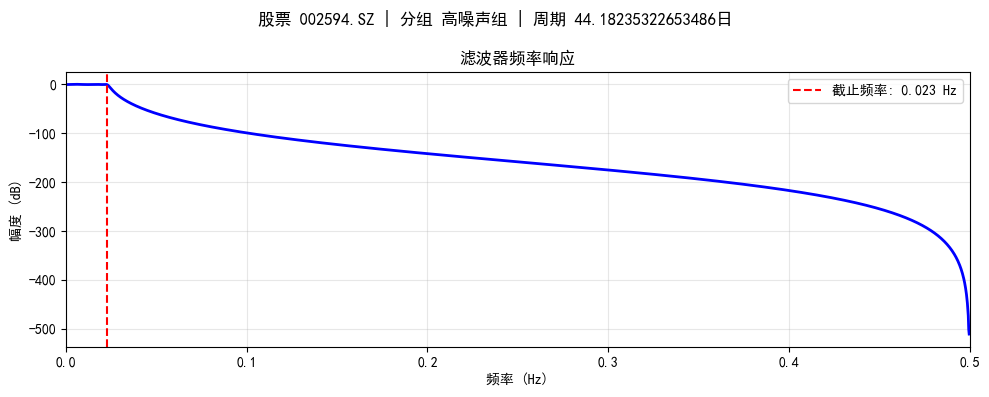

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


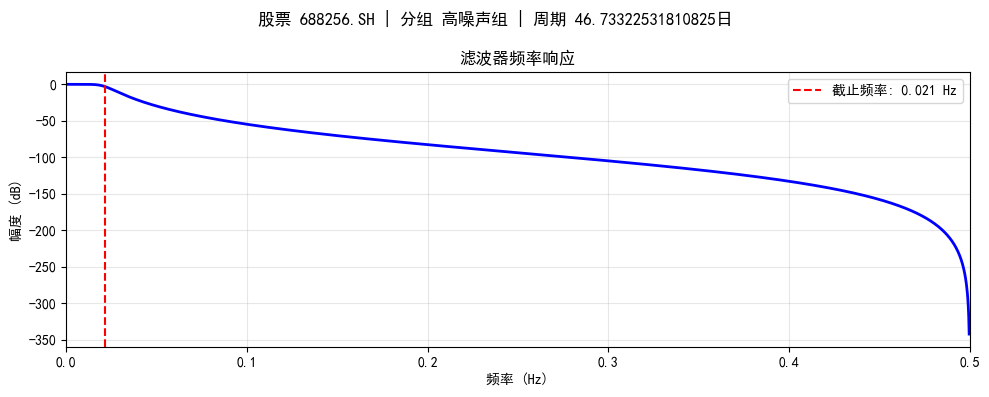

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


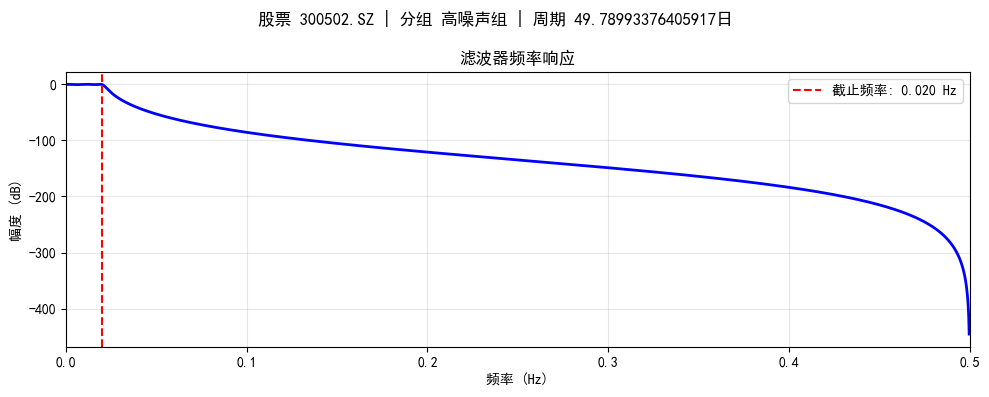

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


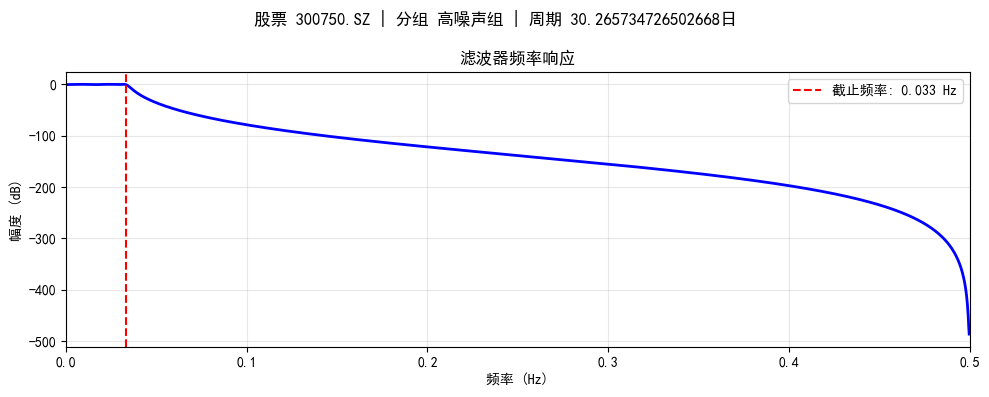

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


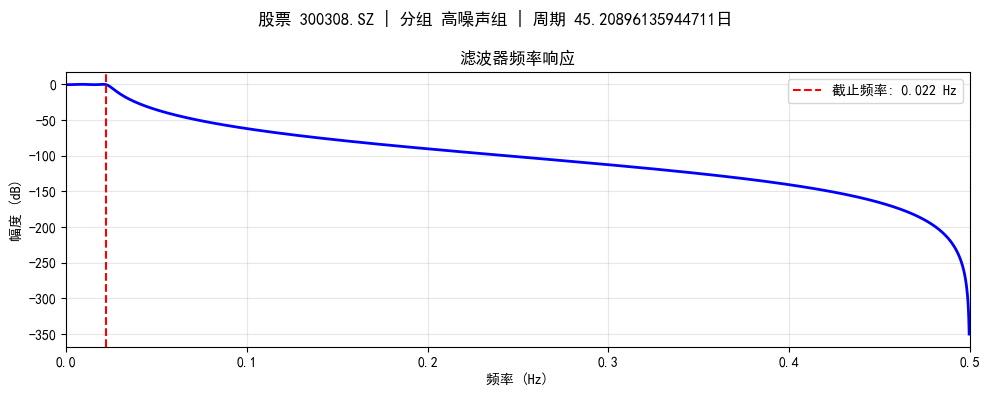

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


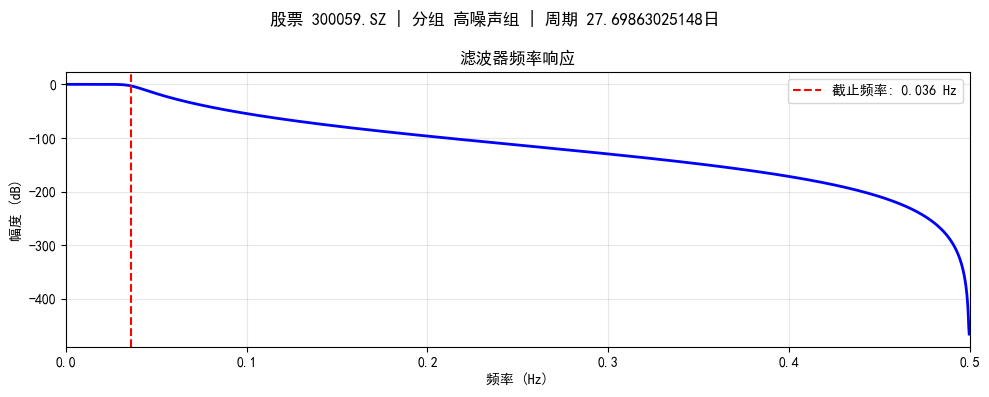

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


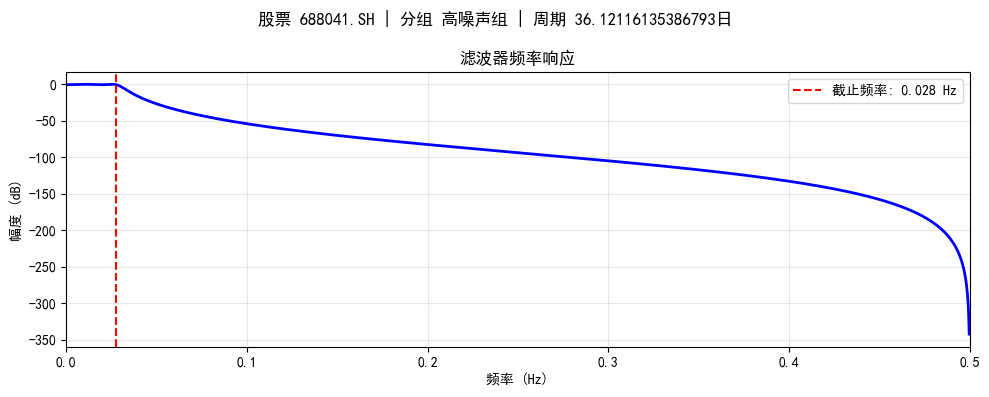

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


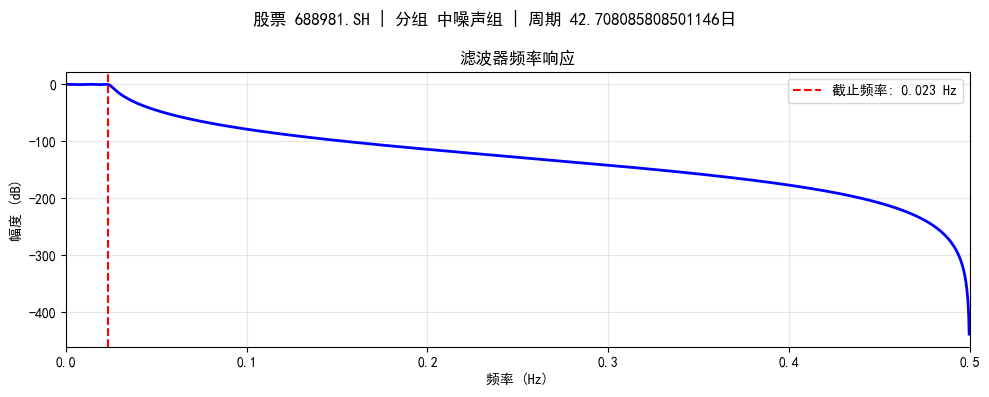

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


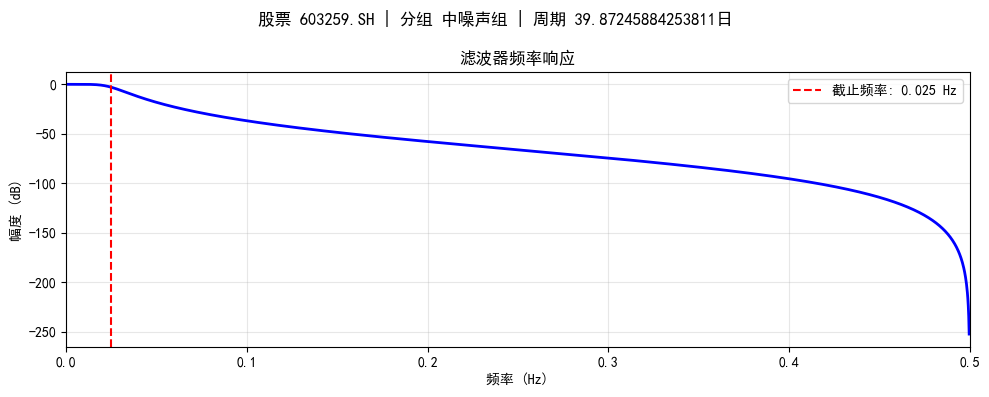

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


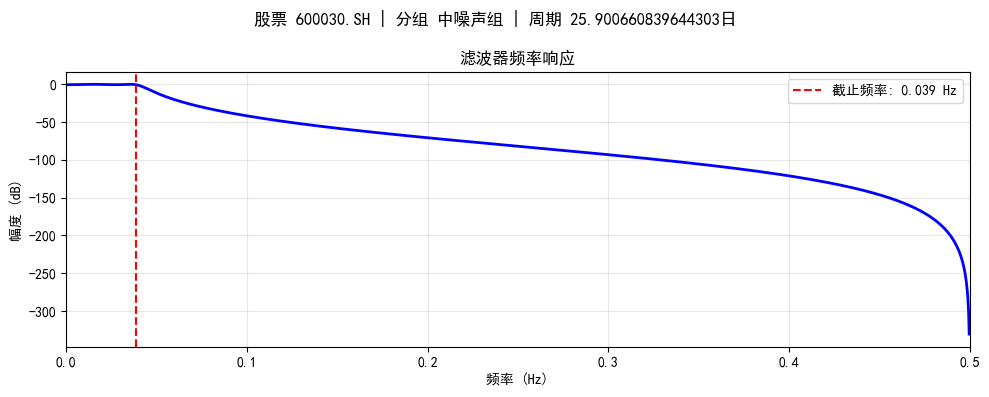

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


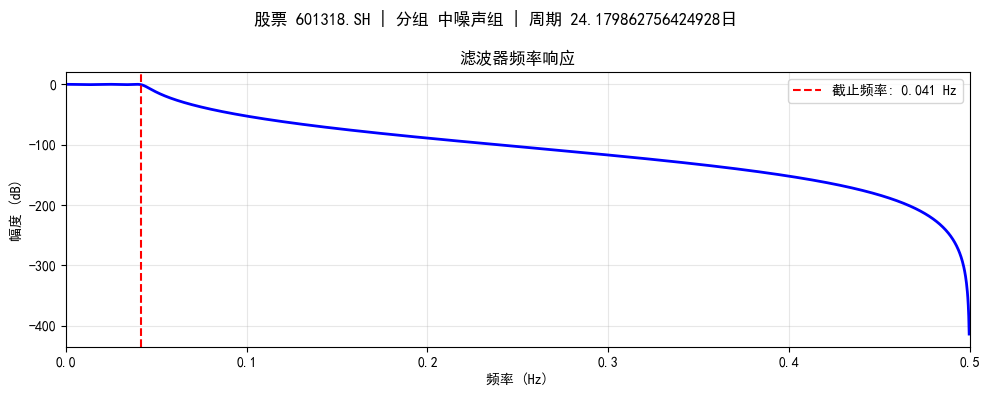

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


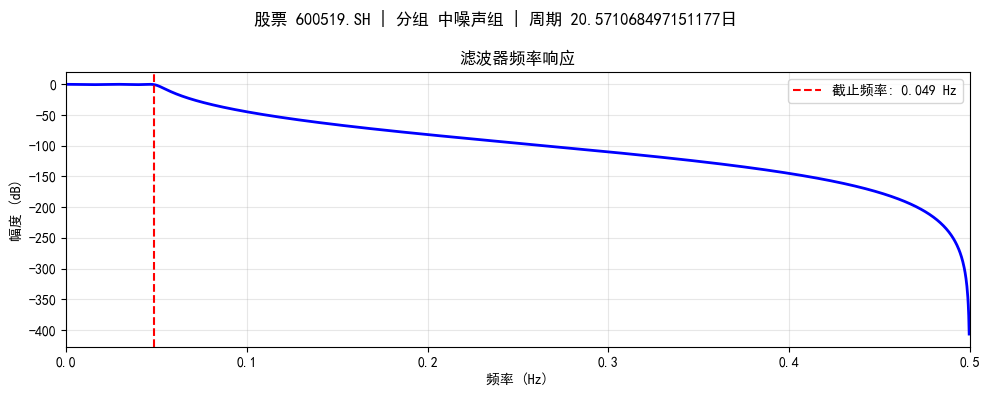

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


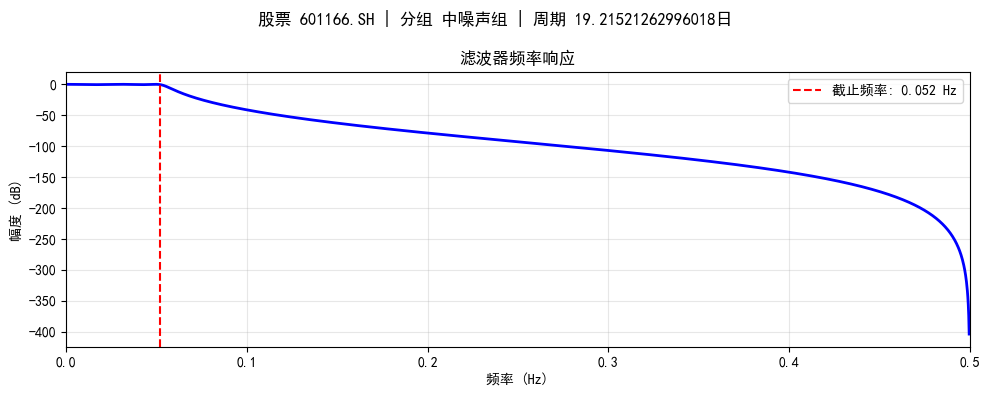

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


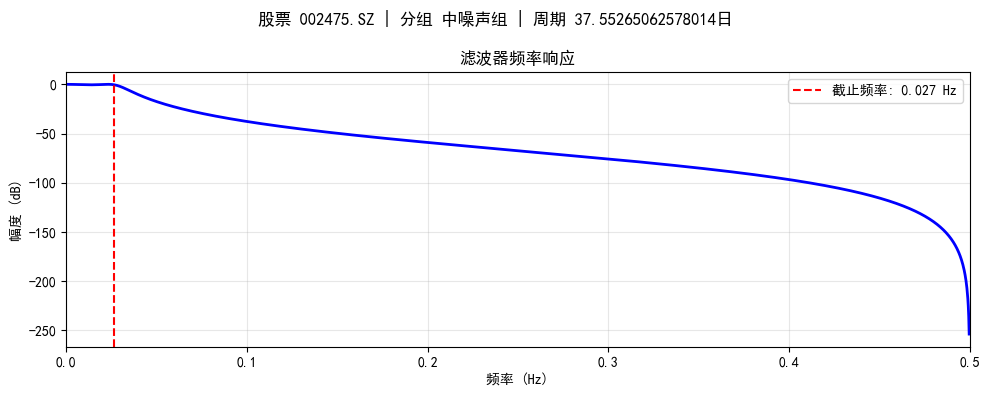

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


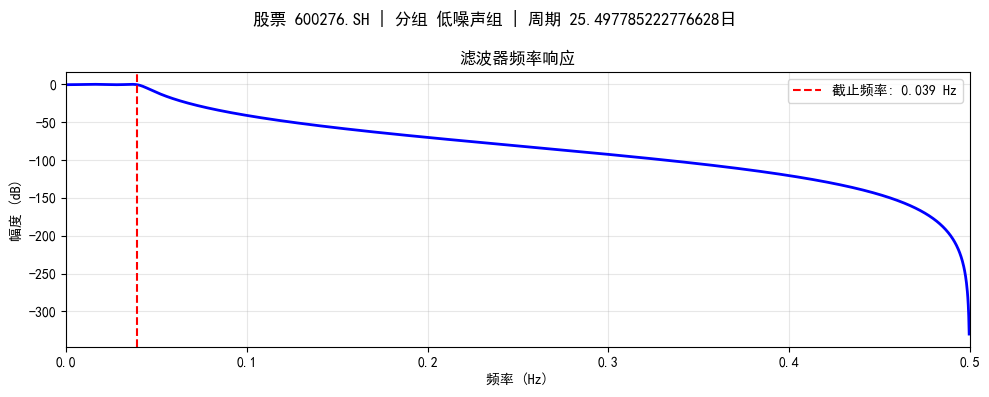

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


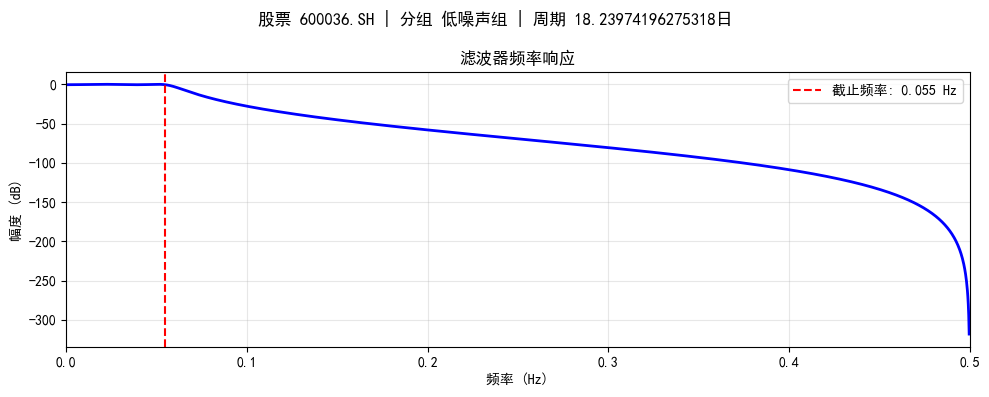

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


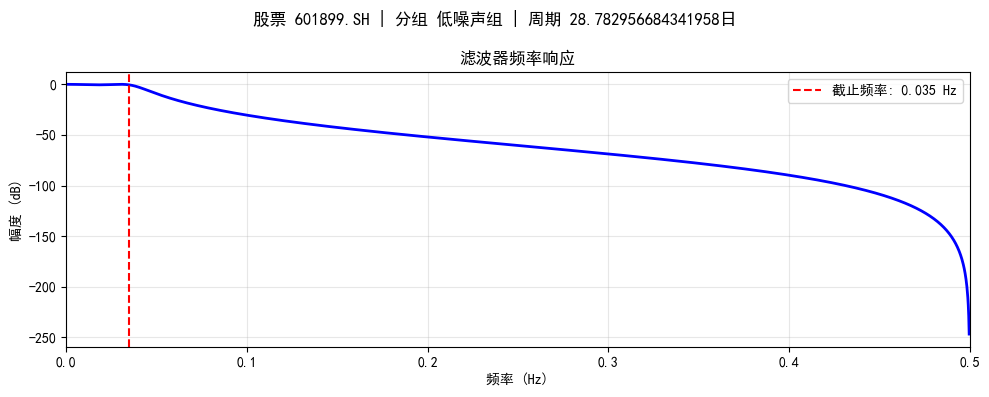

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


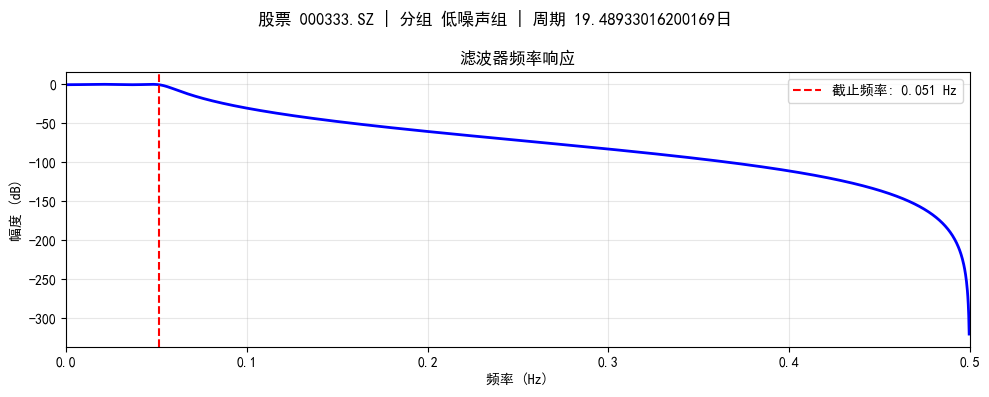

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


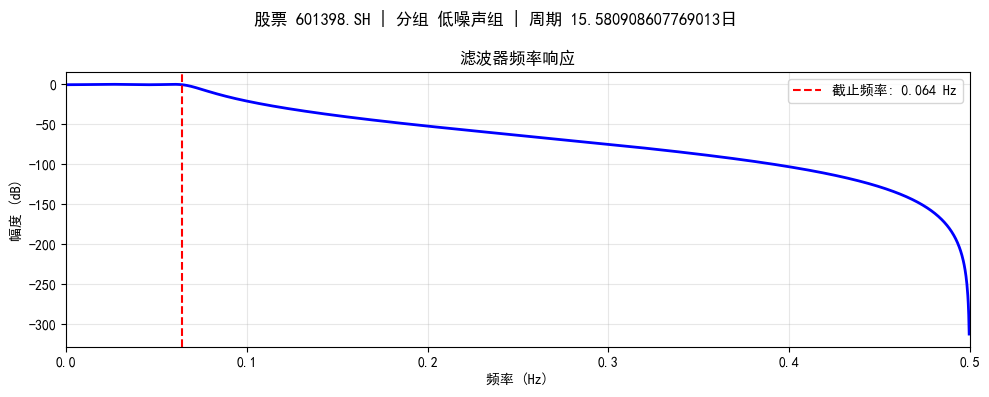

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv


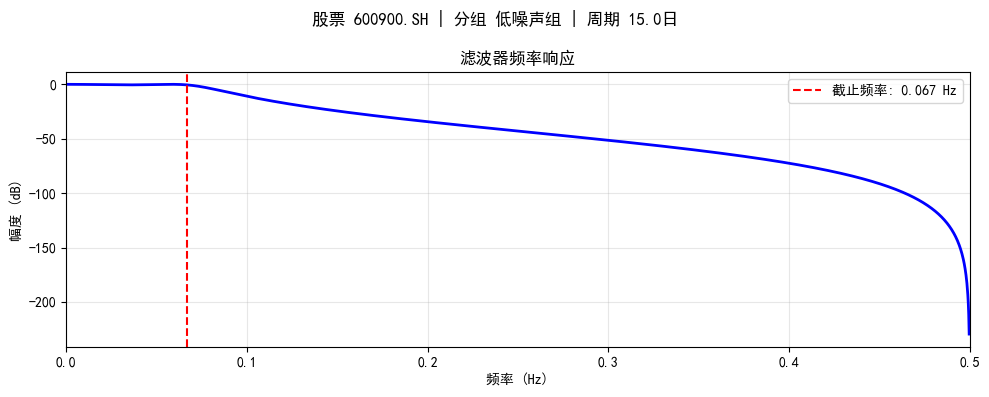

✅ 全股票滤波结果已保存到：全股票滤波结果总表.csv

批量评估完成：
         code group  cutoff_period  noise_reduction  smoothness_ratio  \
0   002594.SZ  高噪声组      44.182353           0.9604            0.0393   
1   688256.SH  高噪声组      46.733225           0.9890            0.0397   
2   300502.SZ  高噪声组      49.789934           0.9866            0.0300   
3   300750.SZ  高噪声组      30.265735           0.9696            0.0517   
4   300308.SZ  高噪声组      45.208961           0.9821            0.0290   
5   300059.SZ  高噪声组      27.698630           0.9823            0.0617   
6   688041.SH  高噪声组      36.121161           0.9777            0.0392   
7   688981.SH  中噪声组      42.708086           0.9874            0.0480   
8   603259.SH  中噪声组      39.872459           0.9804            0.0362   
9   600030.SH  中噪声组      25.900661           0.9737            0.0876   
10  601318.SH  中噪声组      24.179863           0.9851            0.0850   
11  600519.SH  中噪声组      20.571068           0.9710            0.0912   
12  601166.SH 

In [13]:
filter_params_dict = filter_params_df.drop_duplicates('code').set_index('code').to_dict(orient='index')
result_df = batch_evaluate(stock_data, filter_params_dict)
print("\n批量评估完成：")
print(result_df)
result_df.to_csv(r"../数据/评估效果.csv")

In [10]:
#绘制三组的滤波效果对比
def plot_group_comparison(evaluation_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 噪声降低比例
    ax1 = axes[0, 0]
    evaluation_df.boxplot(column='noise_reduction', by='group', ax=ax1)
    ax1.set_title('各分组噪声降低比例')
    ax1.set_ylabel('噪声降低比例')
    ax1.grid(True, alpha=0.3)
    
    # 2. 平滑度比率
    ax2 = axes[0, 1]
    evaluation_df.boxplot(column='smoothness_ratio', by='group', ax=ax2)
    ax2.set_title('各分组平滑度比率（越小越平滑）')
    ax2.set_ylabel('平滑度比率')
    ax2.grid(True, alpha=0.3)
    
    # 3. 趋势保留度
    ax3 = axes[1, 0]
    evaluation_df.boxplot(column='trend_correlation', by='group', ax=ax3)
    ax3.set_title('各分组趋势保留度（越高越好）')
    ax3.set_ylabel('趋势相关性')
    ax3.grid(True, alpha=0.3)
    
    # 4. 信息损失率
    ax4 = axes[1, 1]
    evaluation_df.boxplot(column='information_loss', by='group', ax=ax4)
    ax4.set_title('各分组信息损失率（越低越好）')
    ax4.set_ylabel('信息损失率')
    ax4.grid(True, alpha=0.3)
    
    #能量保留度
    ax5 = axes[1, 1]
    evaluation_df.boxplot(column='energy_remaining', by='group', ax=ax5)
    ax5.set_title('各分组能量保留比例（越高越好）')
    ax5.set_ylabel('能量保留比例')
    ax5.grid(True, alpha=0.3)

    plt.suptitle('滤波效果分组对比', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('滤波效果分组对比.png', dpi=150)
    plt.show()
    
    # 输出统计汇总
    print("\n=== 滤波效果统计汇总 ===")
    for group in ['高噪声组', '中噪声组', '低噪声组']:
        group_data = evaluation_df[evaluation_df['group'] == group]
        print(f"\n{group}:")
        print(f"  噪声降低: {group_data['noise_reduction'].mean():.2%}")
        print(f"  平滑度: {group_data['smoothness_ratio'].mean():.3f}")
        print(f"  趋势保留: {group_data['trend_correlation'].mean():.3f}")
        print(f"  信息损失: {group_data['information_loss'].mean():.3f}")
        print(f"  能量保留: {group_data['energy_remaining'].mean():.2%}")

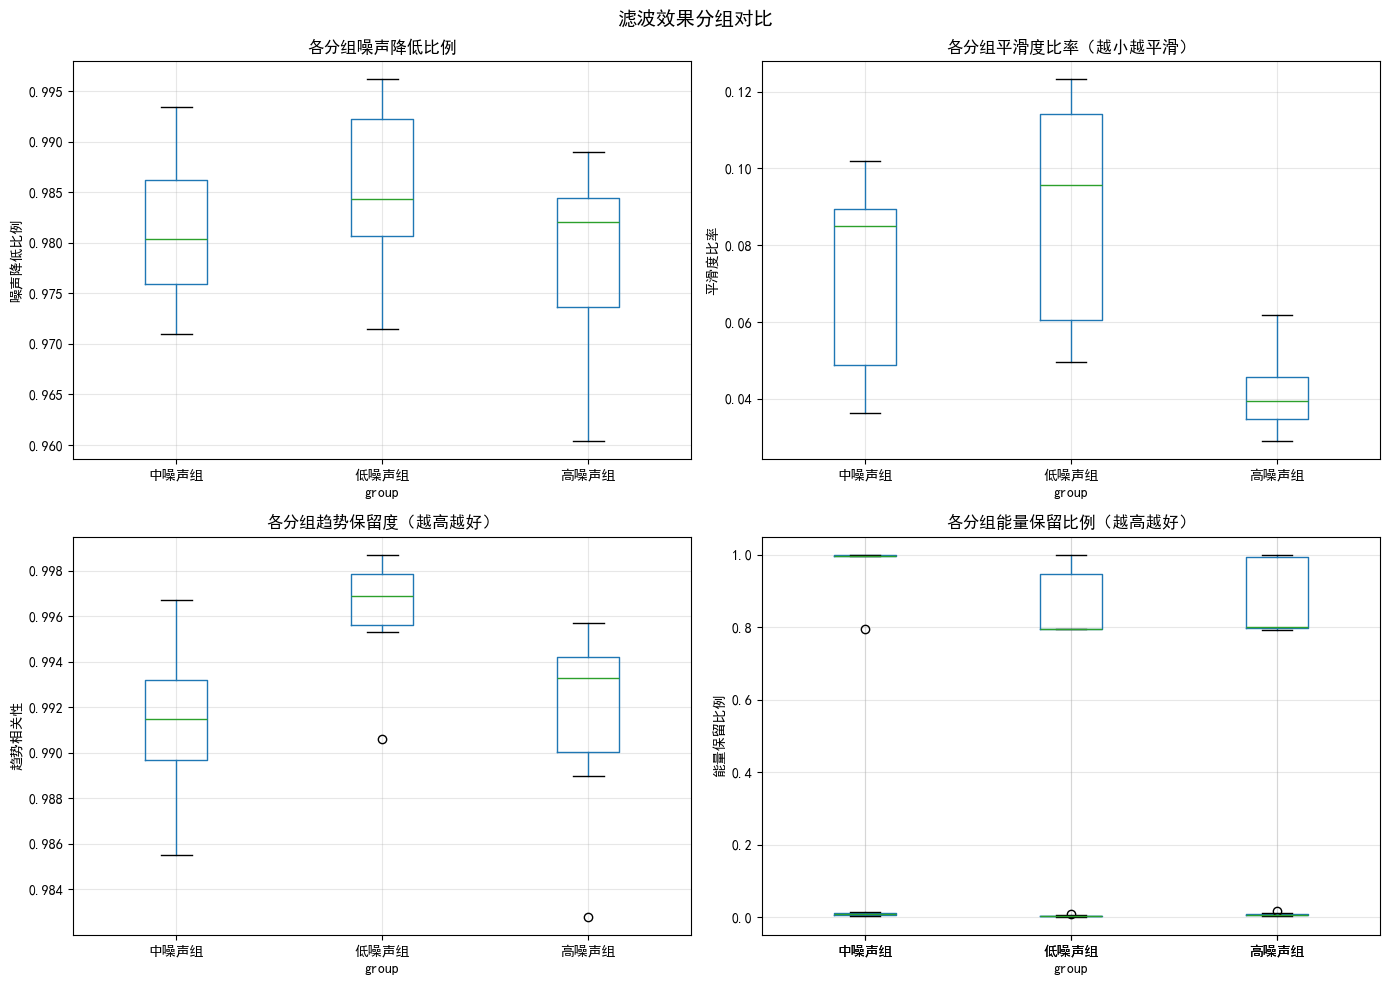


=== 滤波效果统计汇总 ===

高噪声组:
  噪声降低: 97.82%
  平滑度: 0.042
  趋势保留: 0.991
  信息损失: 0.009
  能量保留: 88.22%

中噪声组:
  噪声降低: 98.13%
  平滑度: 0.071
  趋势保留: 0.991
  信息损失: 0.009
  能量保留: 96.91%

低噪声组:
  噪声降低: 98.51%
  平滑度: 0.089
  趋势保留: 0.996
  信息损失: 0.004
  能量保留: 86.26%


In [11]:
plot_group_comparison(result_df)